In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import os
import sys
from dateutil.relativedelta import relativedelta
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.fft import fft, fftfreq
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.deterministic import DeterministicProcess
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8-whitegrid')
plt.rc(
    "figure",
    autolayout=True,
    figsize=(11, 4),
    titlesize=18,
    titleweight='bold',
)
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=16,
    titlepad=10,
)
plot_params = dict(
    color="0.75",
    style=".-",
    markeredgecolor="0.25",
    markerfacecolor="0.25",
    legend=False,
)
%config InlineBackend.figure_format = 'retina'
sns.set_palette("husl")

# Data Simulation

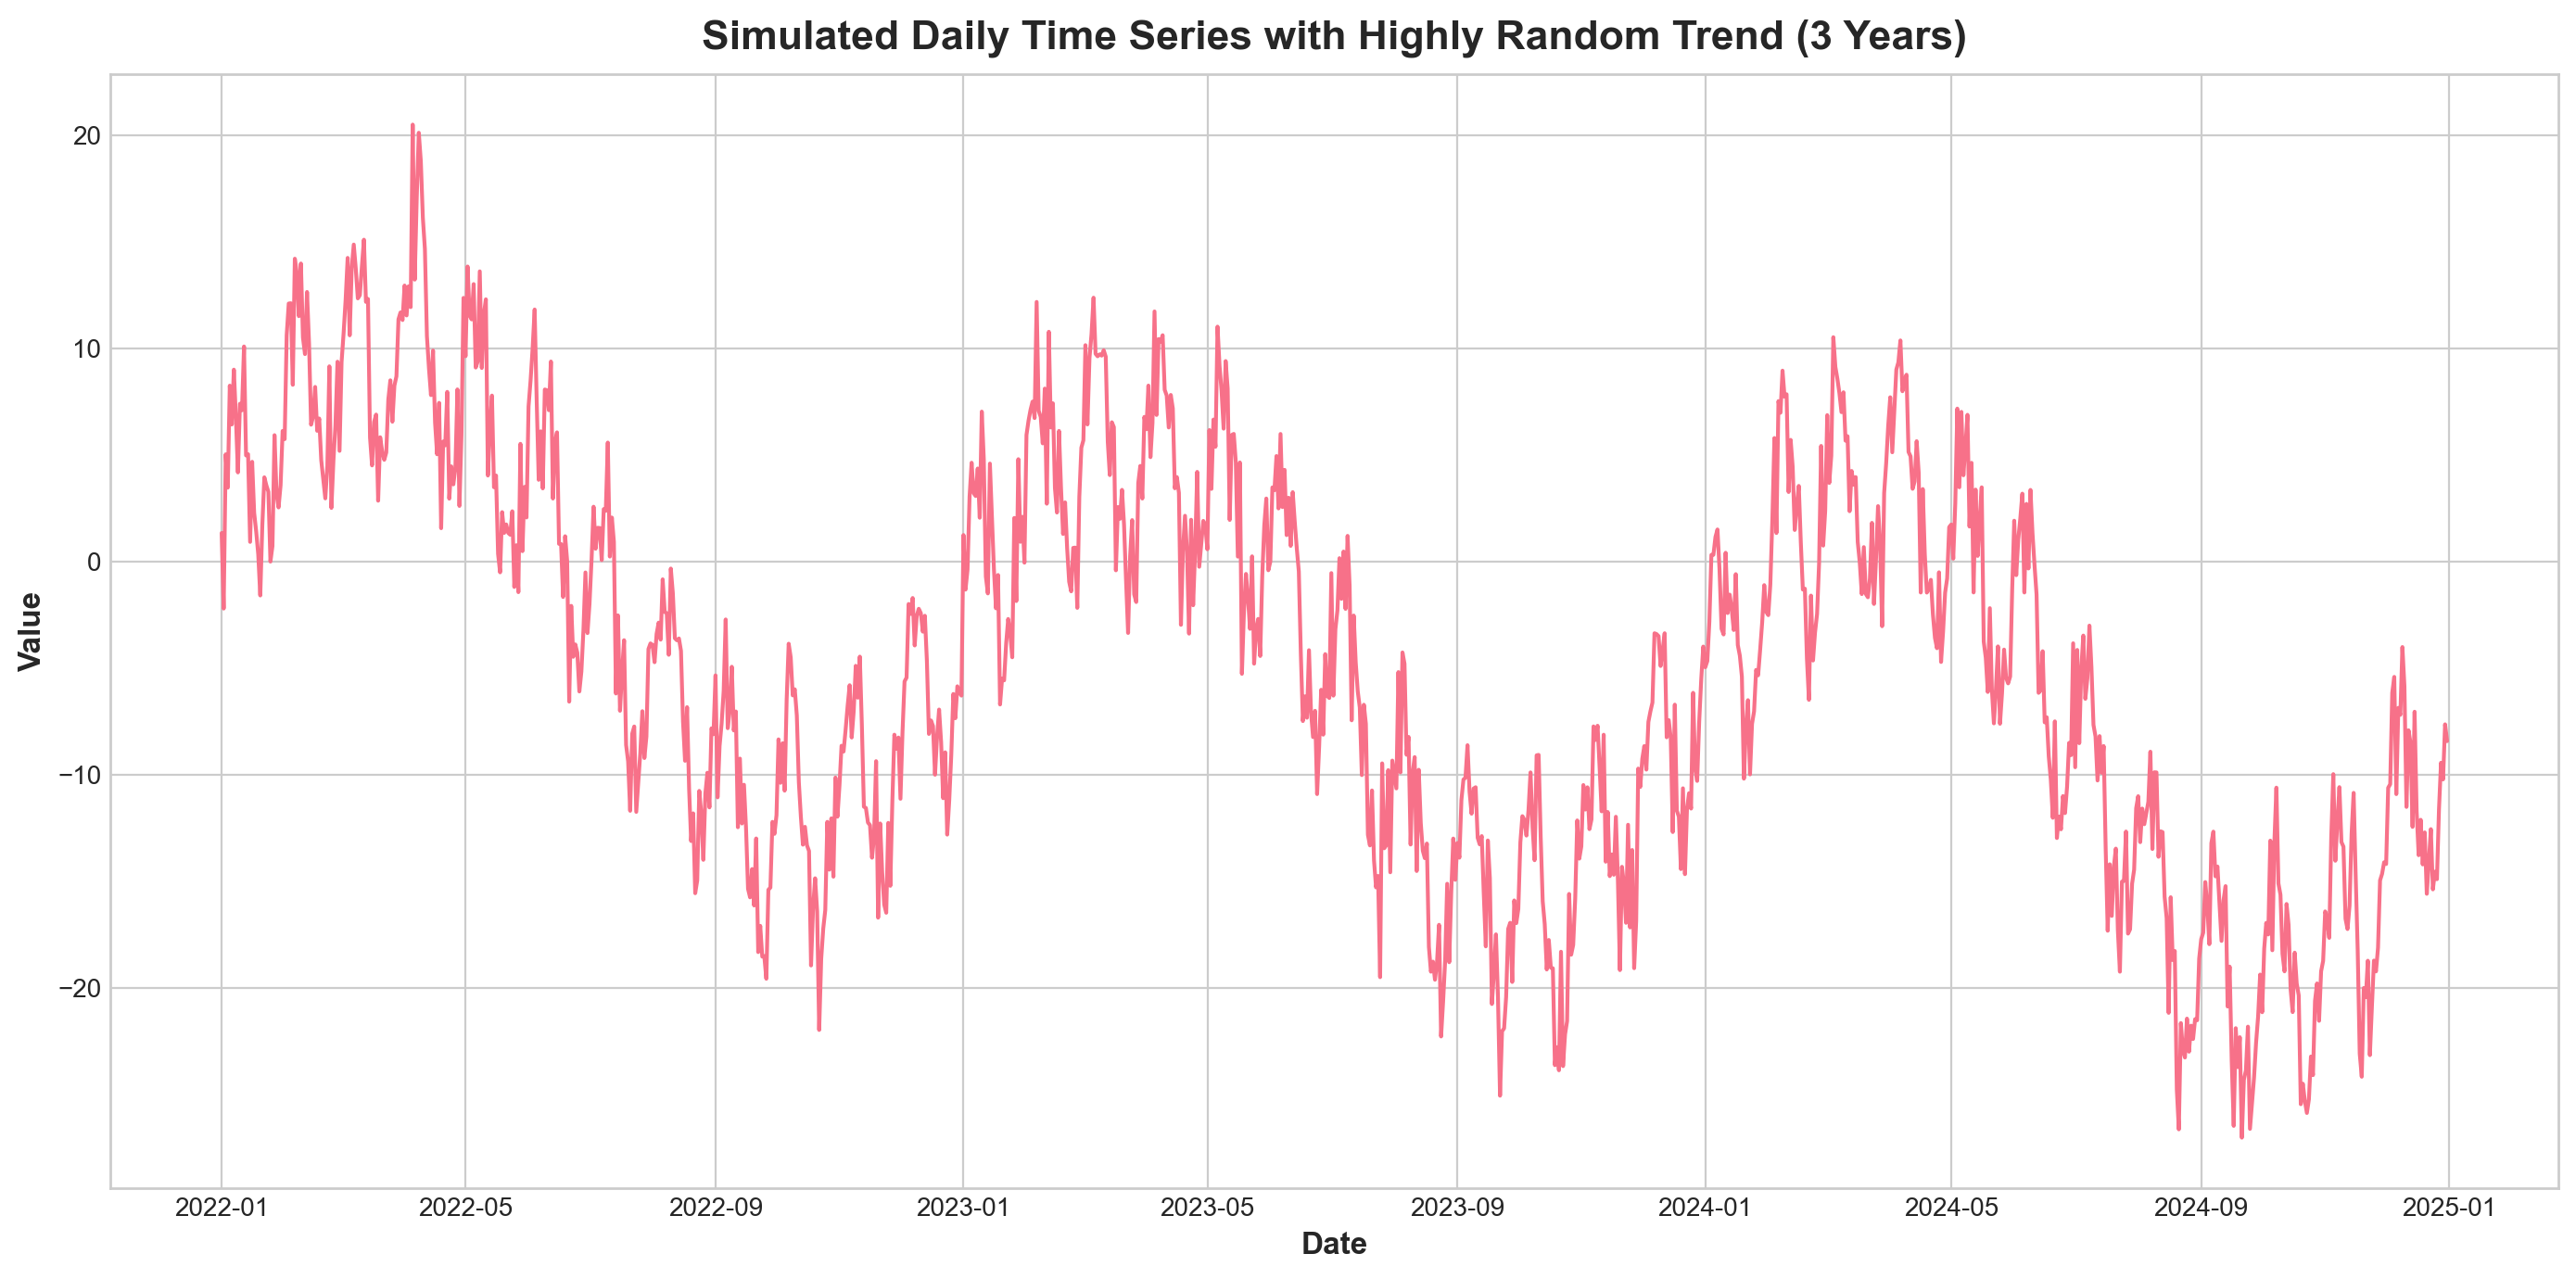

In [2]:
dates = pd.date_range(start='2022-01-01', end='2024-12-31', freq='D')

# Random walk without drift
trend_steps = np.random.normal(loc=[0], scale=0.2, size=len(dates))
trend = np.cumsum(trend_steps)

yearly_seasonality = 10 * np.sin(2 * np.pi * dates.dayofyear / 365)
monthly_seasonality = 5 * np.sin(2 * np.pi * dates.day / 30)
noise = np.random.normal(loc=0, scale=2, size=len(dates))

data = trend + yearly_seasonality + monthly_seasonality + noise

time_series = pd.DataFrame(data, index=dates)
time_series = time_series.reset_index()
time_series.columns = ['date', 'values']

plt.figure(figsize=(14, 7))
plt.plot(time_series.set_index('date')['values'])
plt.title('Simulated Daily Time Series with Highly Random Trend (3 Years)')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True)
plt.show()

# Time Series Forcastor

In [3]:
# notebook_dir = os.getcwd()
# project_root = os.path.abspath(os.path.join(notebook_dir, os.pardir, os.pardir))
# src_root = os.path.join(project_root, "src")
# if src_root not in sys.path:
#     sys.path.append(src_root)
#     print(f"Added {src_root!r} to the Python path")

from estatecnica.time_series import TimeSeriesAnalyzer, TimeSeriesForcastor
from estatecnica.time_series.simulation import ARIMASimulator


In [4]:
# TimeSeriesForcastor is imported from estatecnica.time_series


In [5]:
time_series_forecastor = TimeSeriesForcastor(time_series, date_column = 'date', value_column = 'values')

## Baseline model for Benchmark

Models used for a benchmark to compare with complicated models and see if they perform better than the benchmark or not.

### Naive forecasting model

Every forecast value is set to the last observed value from the data. While useful as a benchmark, this method is not expected to be accurate at all.

In [6]:
# data got assigned with last day value
(time_series_forecastor.naive_pred == time_series_forecastor.train_ts.iloc[-1]).all()

np.True_

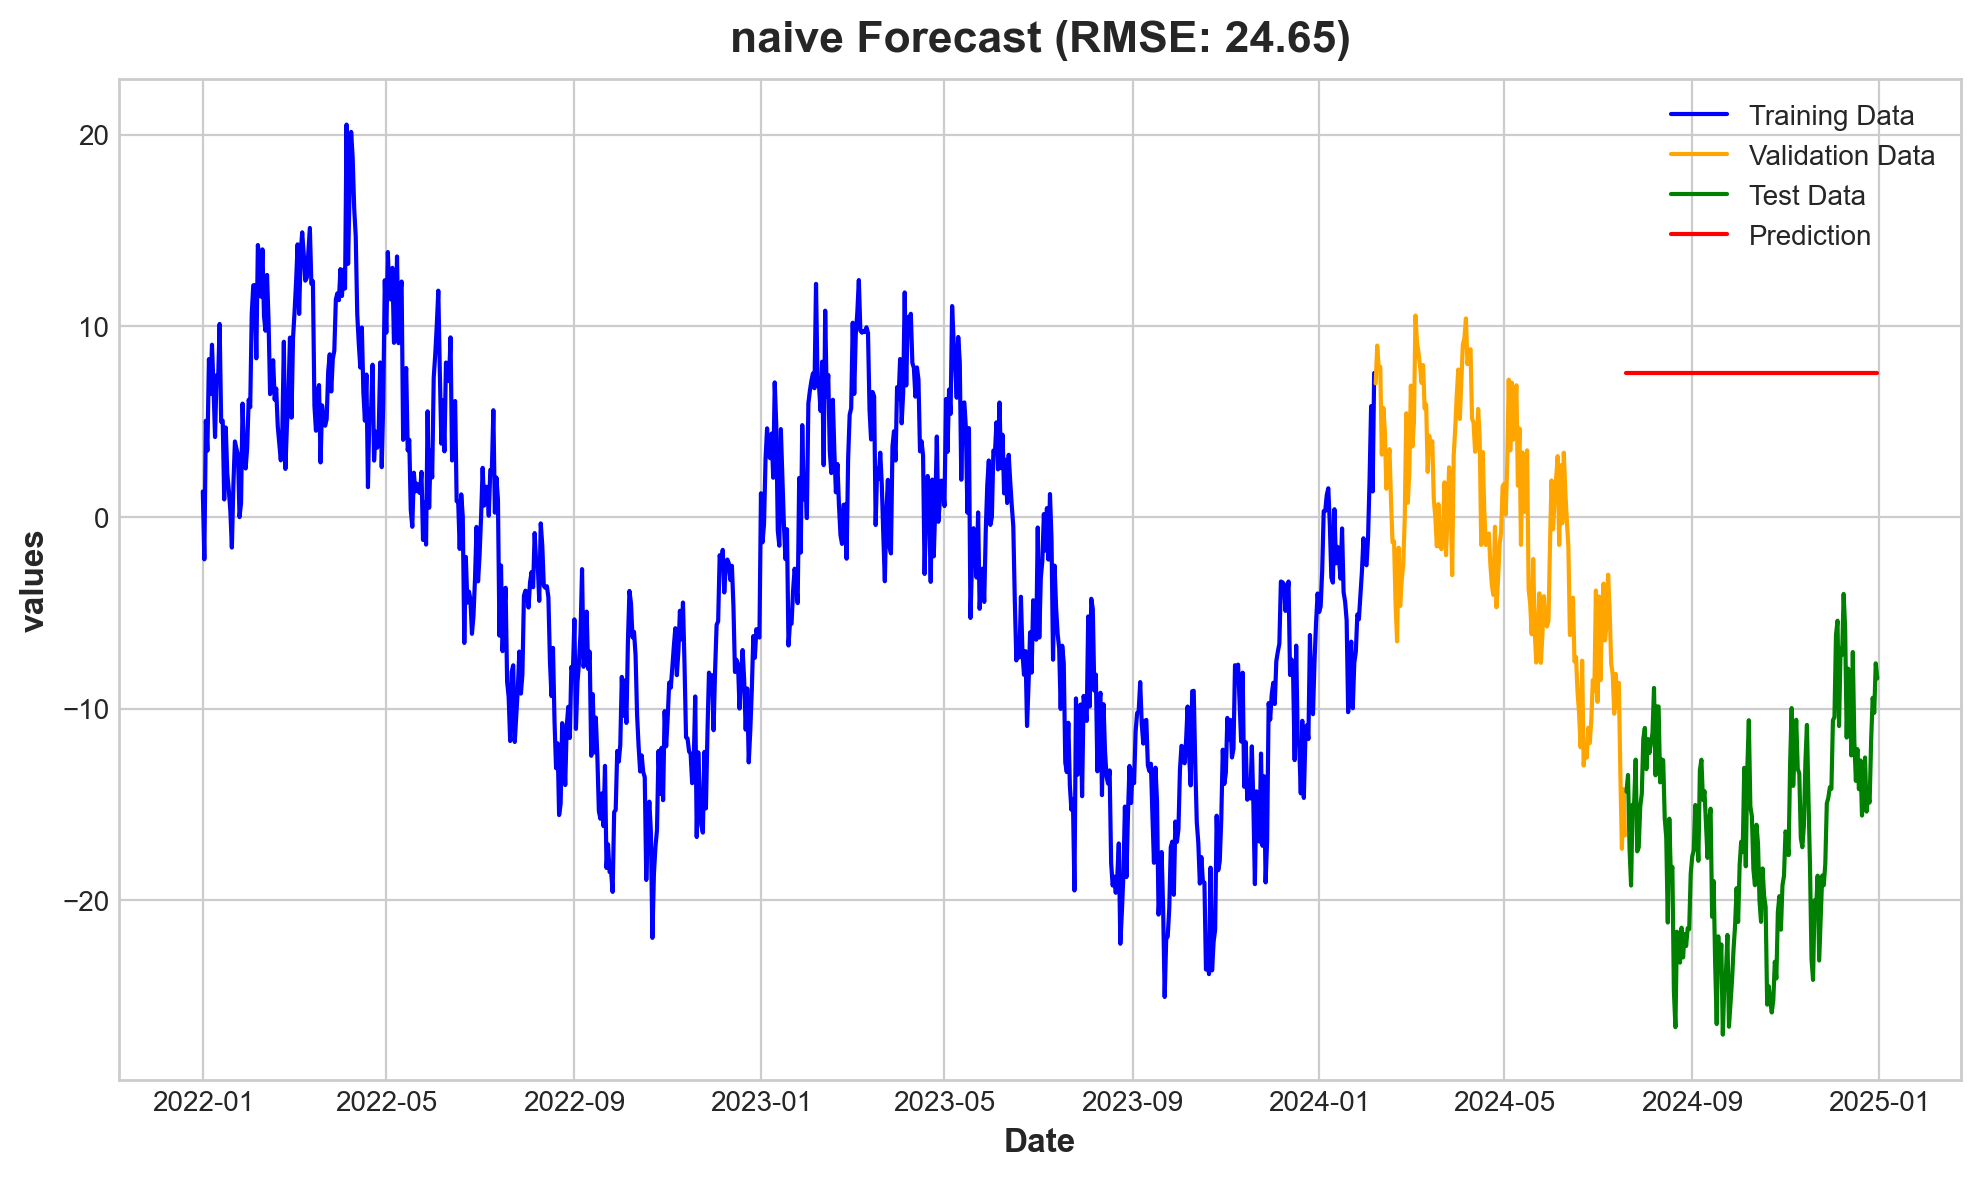

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'naive Forecast (RMSE: 24.65)'}, xlabel='Date', ylabel='values'>)

In [7]:
# plot the train, test and pred
time_series_forecastor.plot_pred_basic()

In [8]:
# show the mean square error to check the accuracy
time_series_forecastor.naive_rmse

24.65414146632436

### Average forecasting model

All forecast values are set to the average of the training data. This method serves as a benchmark and is expected to perform better than a naive forecasting model.

In [9]:
# data got assigned with average value of the train dataset
(time_series_forecastor.aver_pred == time_series_forecastor.train_ts.mean()).all()

np.True_

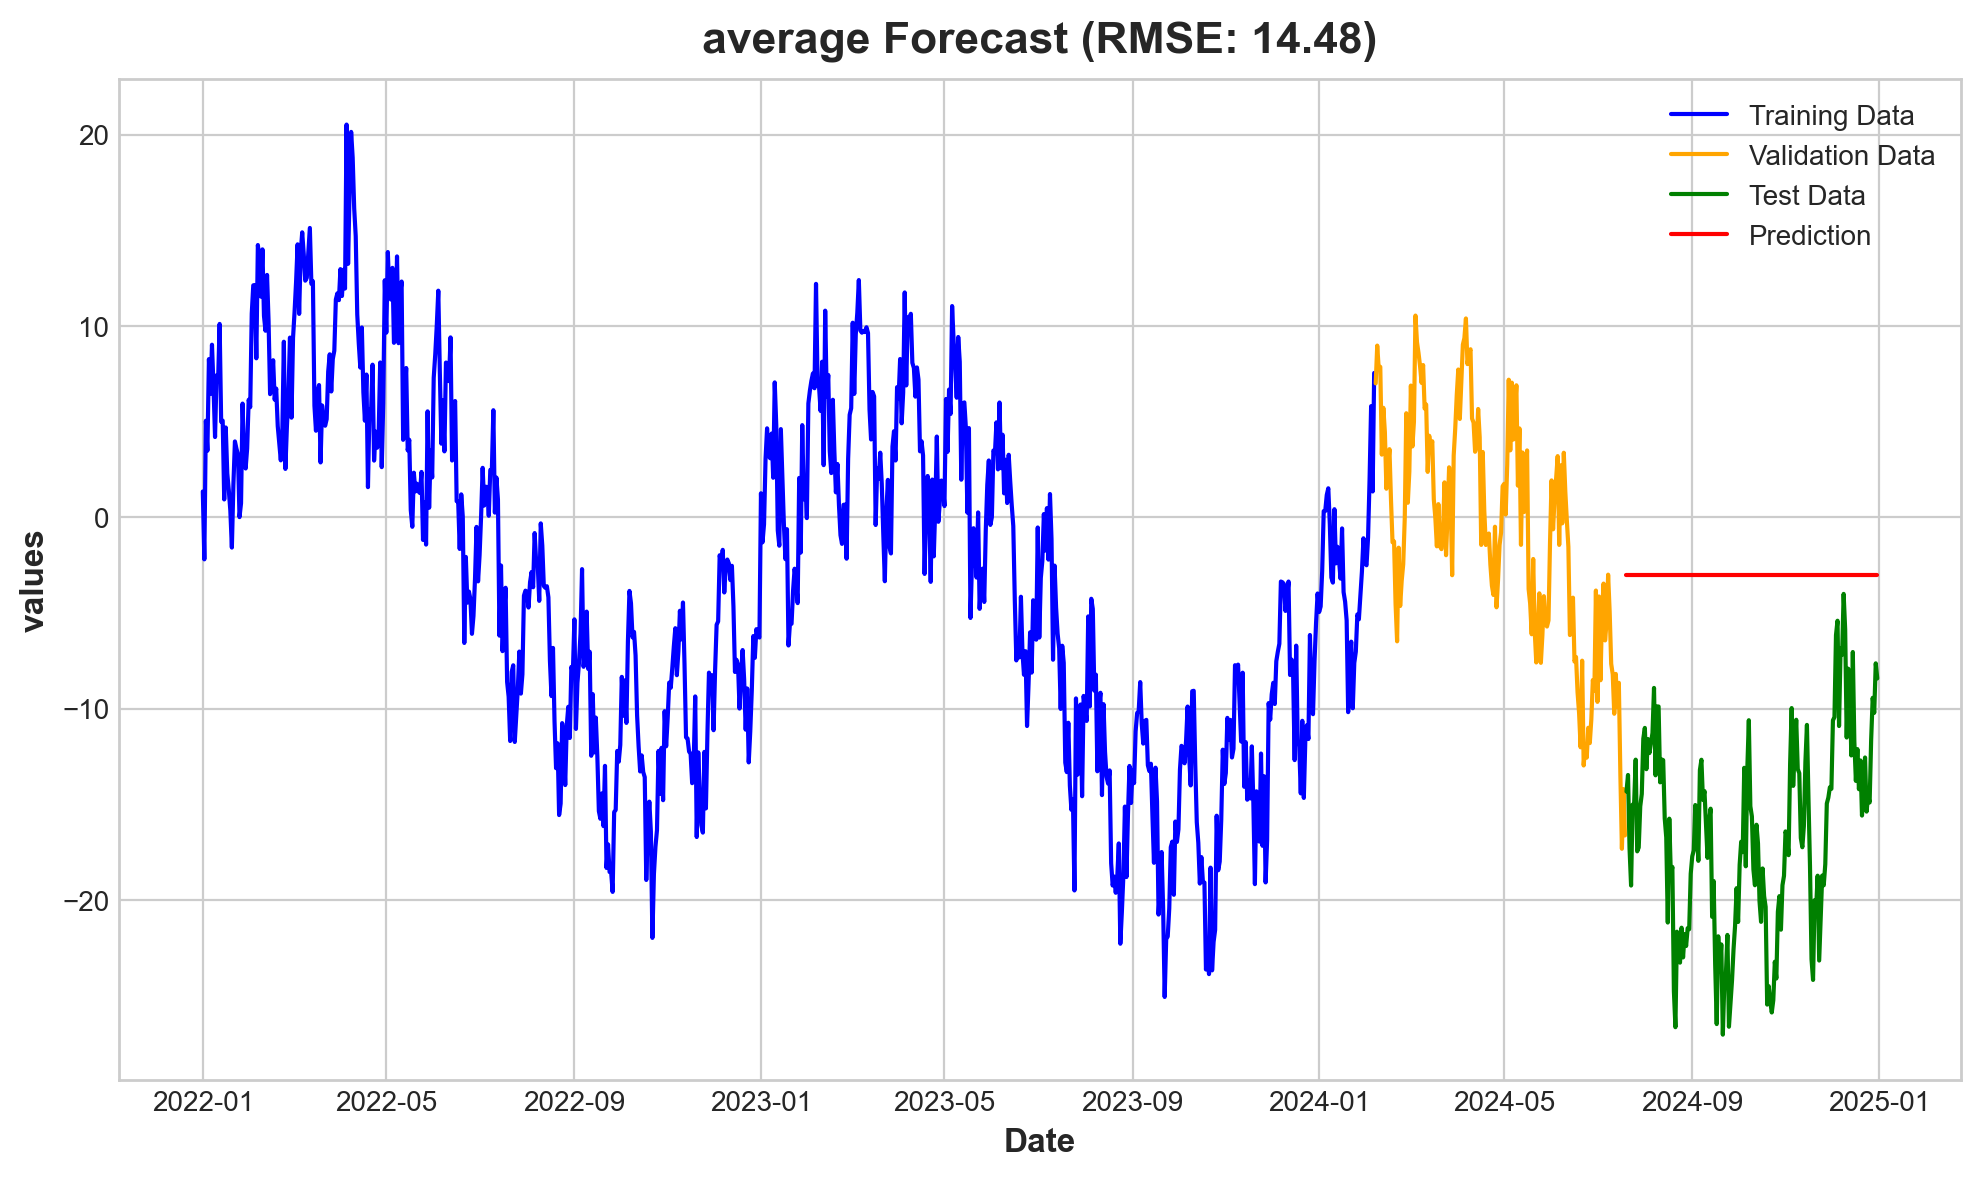

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'average Forecast (RMSE: 14.48)'}, xlabel='Date', ylabel='values'>)

In [10]:
# plot the train, test and pred
time_series_forecastor.plot_pred_basic(method='average')

In [11]:
# show the mean square error to check the accuracy
time_series_forecastor.aver_rmse

14.47884059721847

### Simple Drift Forecasting Model

To generate a prediction, the slope is first calculated from the first and last values, and then used to extrapolate from the final value for a length matching the test data.

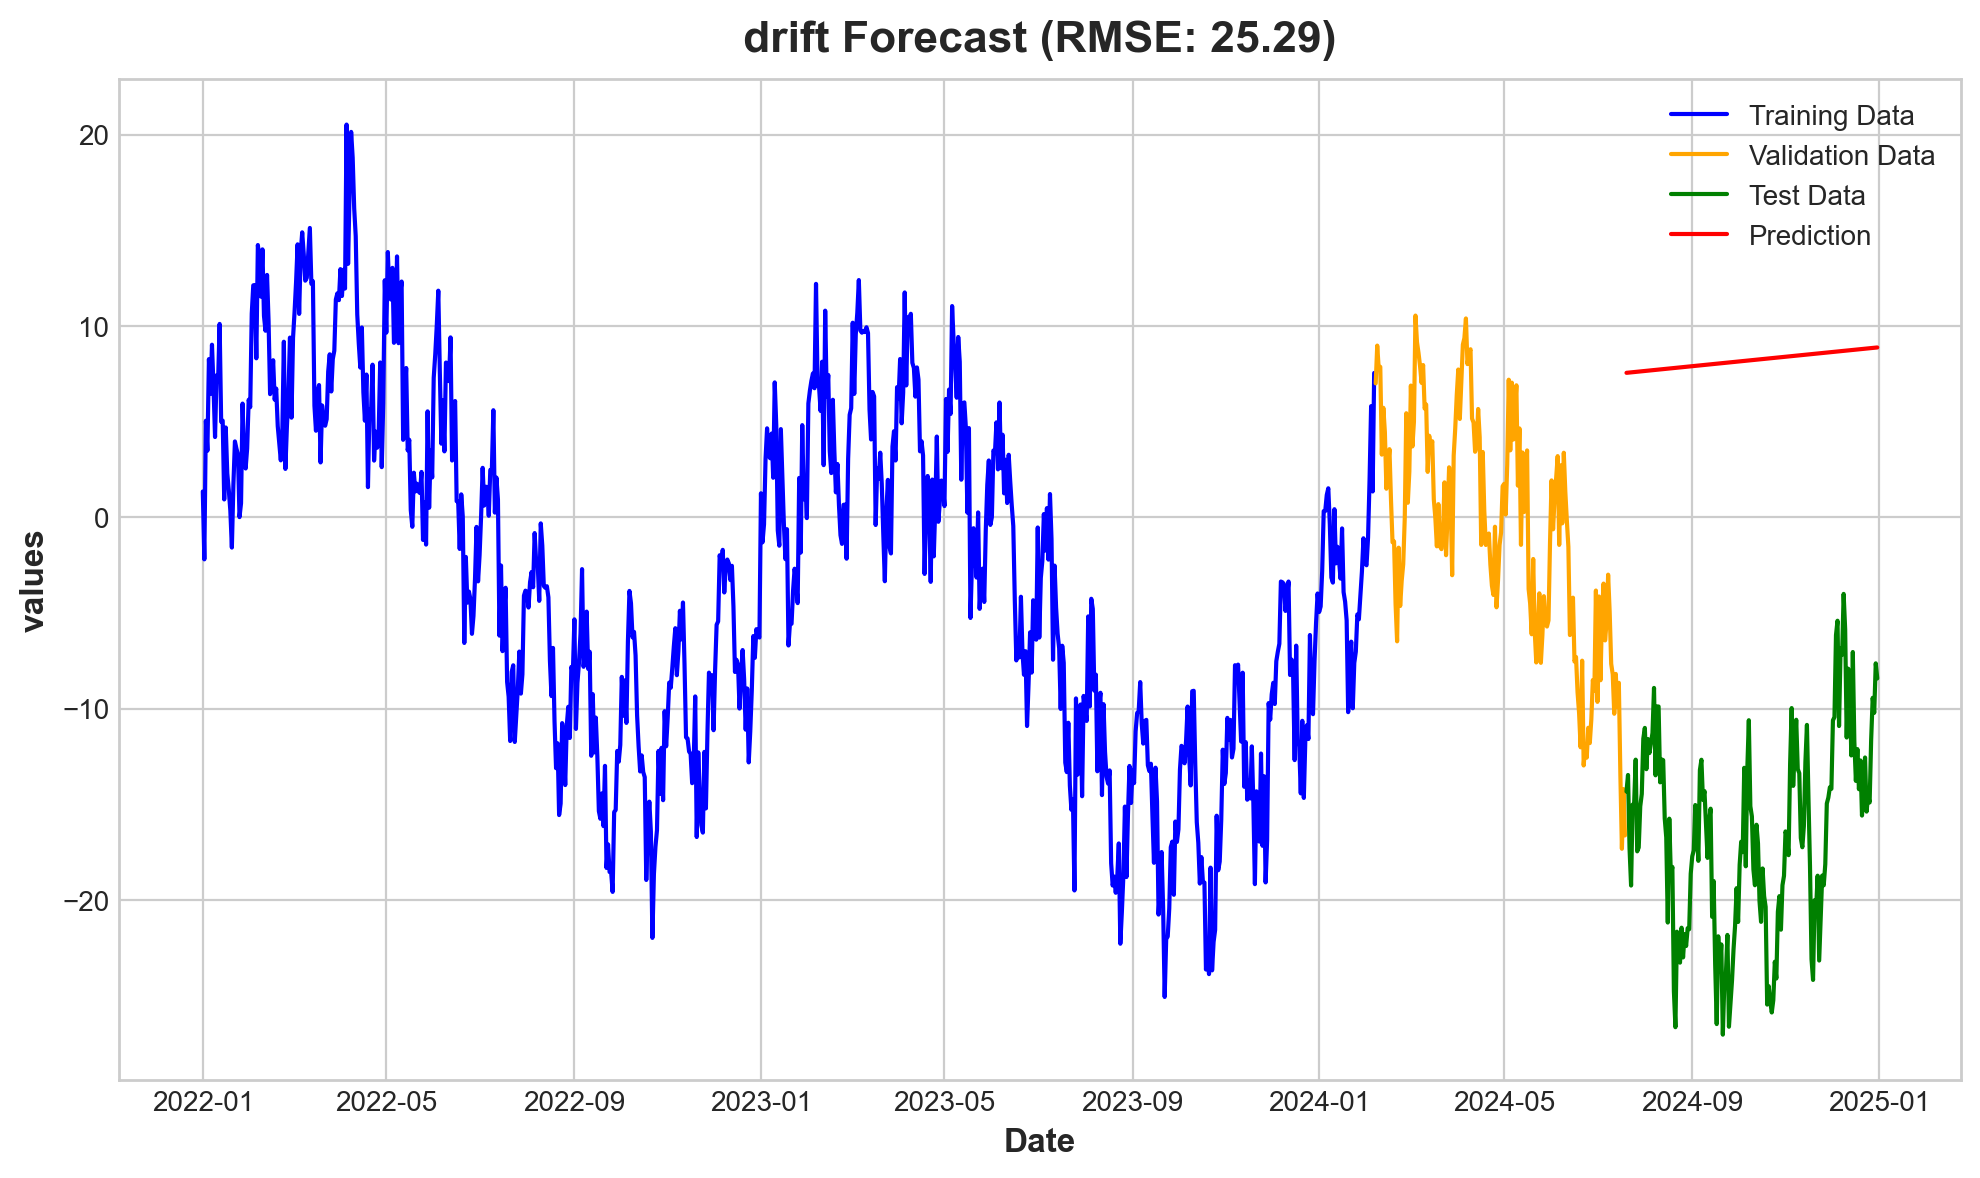

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'drift Forecast (RMSE: 25.29)'}, xlabel='Date', ylabel='values'>)

In [12]:
# plot the train, test and pred
time_series_forecastor.plot_pred_basic(method='sim_drift')

In [13]:
# show the mean square error to check the accuracy
time_series_forecastor.sim_drift_rmse

25.292685236760533

### Seasonal Naive Forecasting Model (Default = last 7 days)

This method creates a forecast by repeating the pattern of the last seasonal period. The length of the forecast is set to match the test data for comparison.

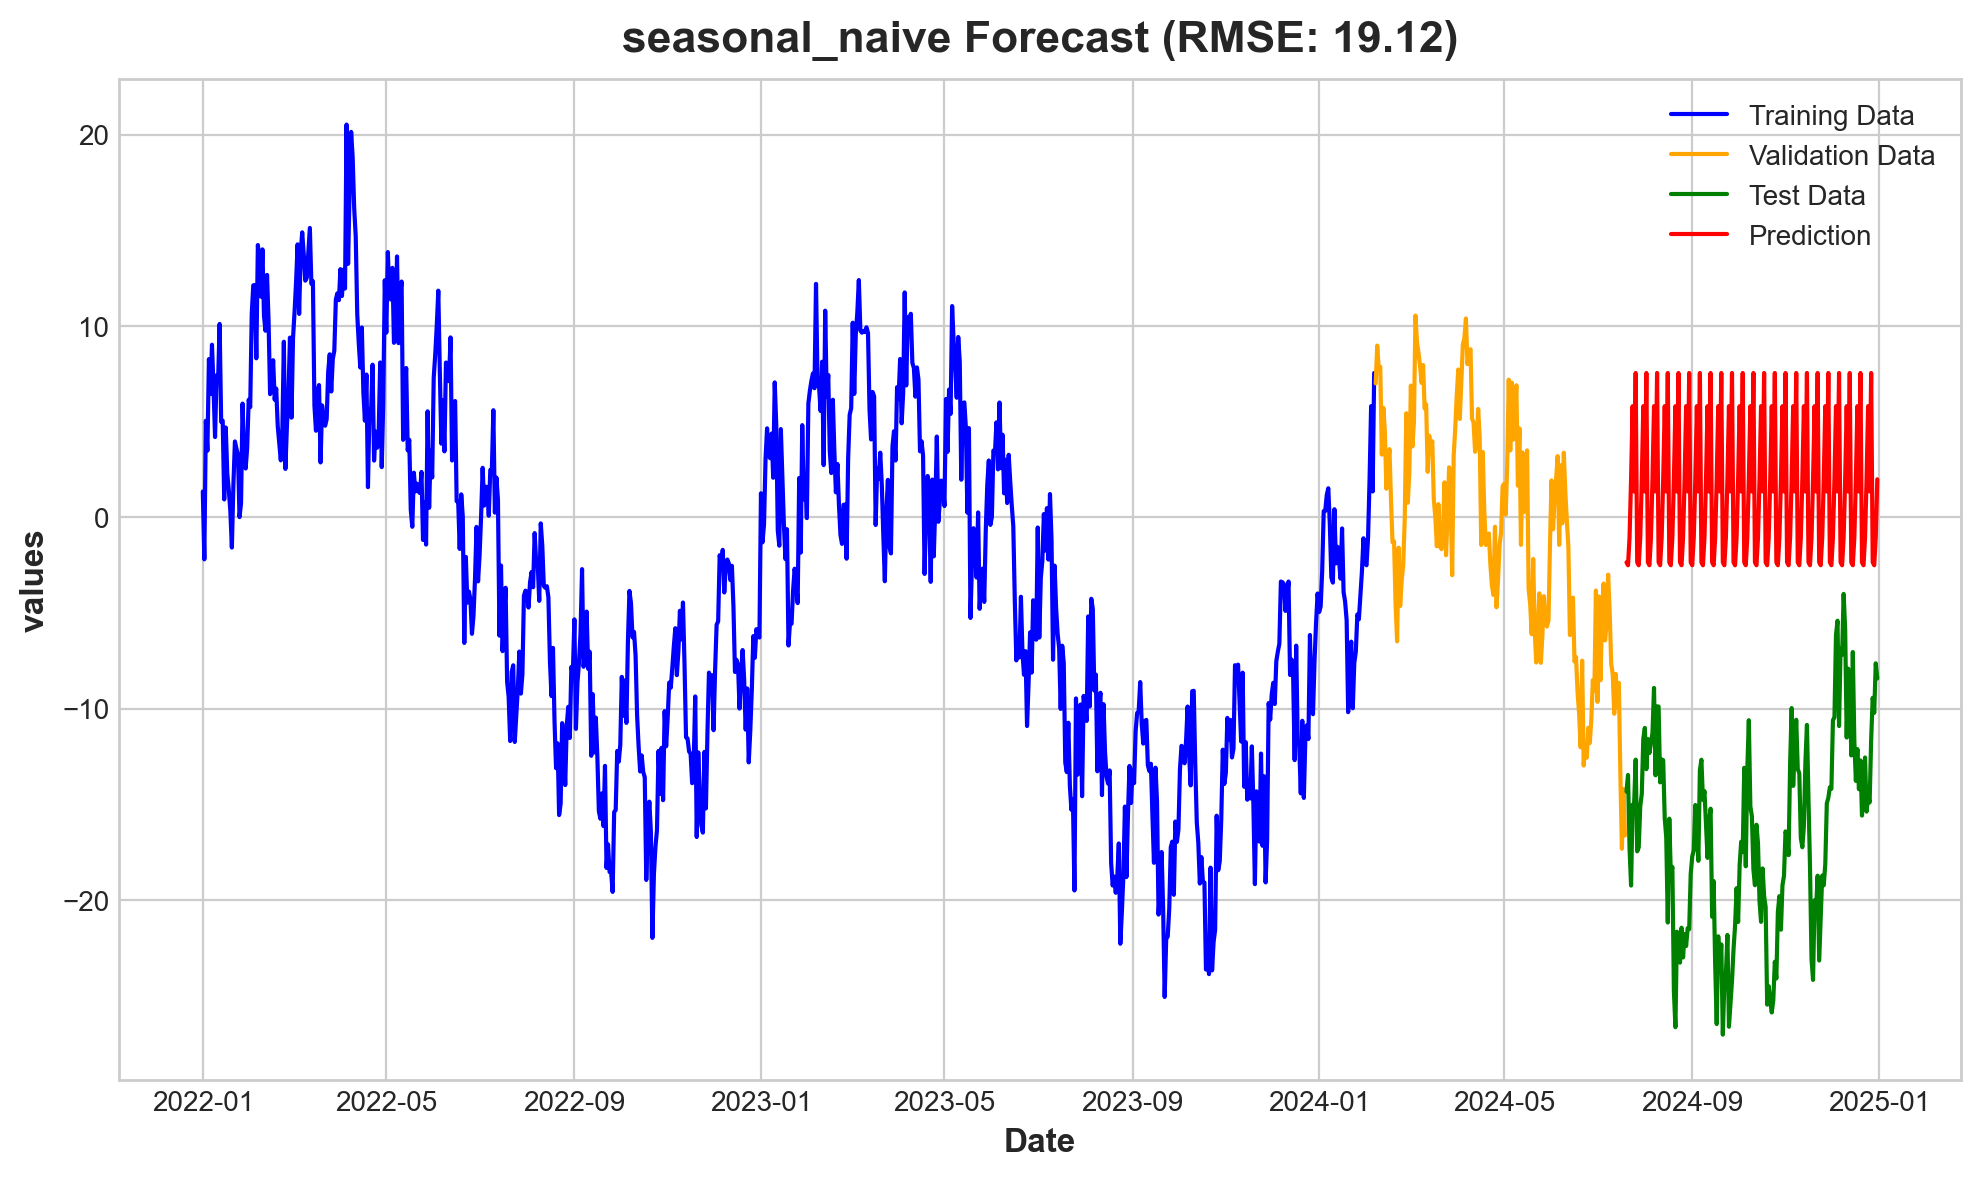

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'seasonal_naive Forecast (RMSE: 19.12)'}, xlabel='Date', ylabel='values'>)

In [14]:
# plot the train, test and pred
time_series_forecastor.plot_pred_basic(method='season_naive')

In [15]:
# show the mean square error to check the accuracy
time_series_forecastor.seasonal_week_rmse

19.120397269177424

### Recent Drift Forecasting Model (Default = last 30 days)

A window of recent data is selected from the end of the training set. The slope of this window is then calculated to generate the prediction.

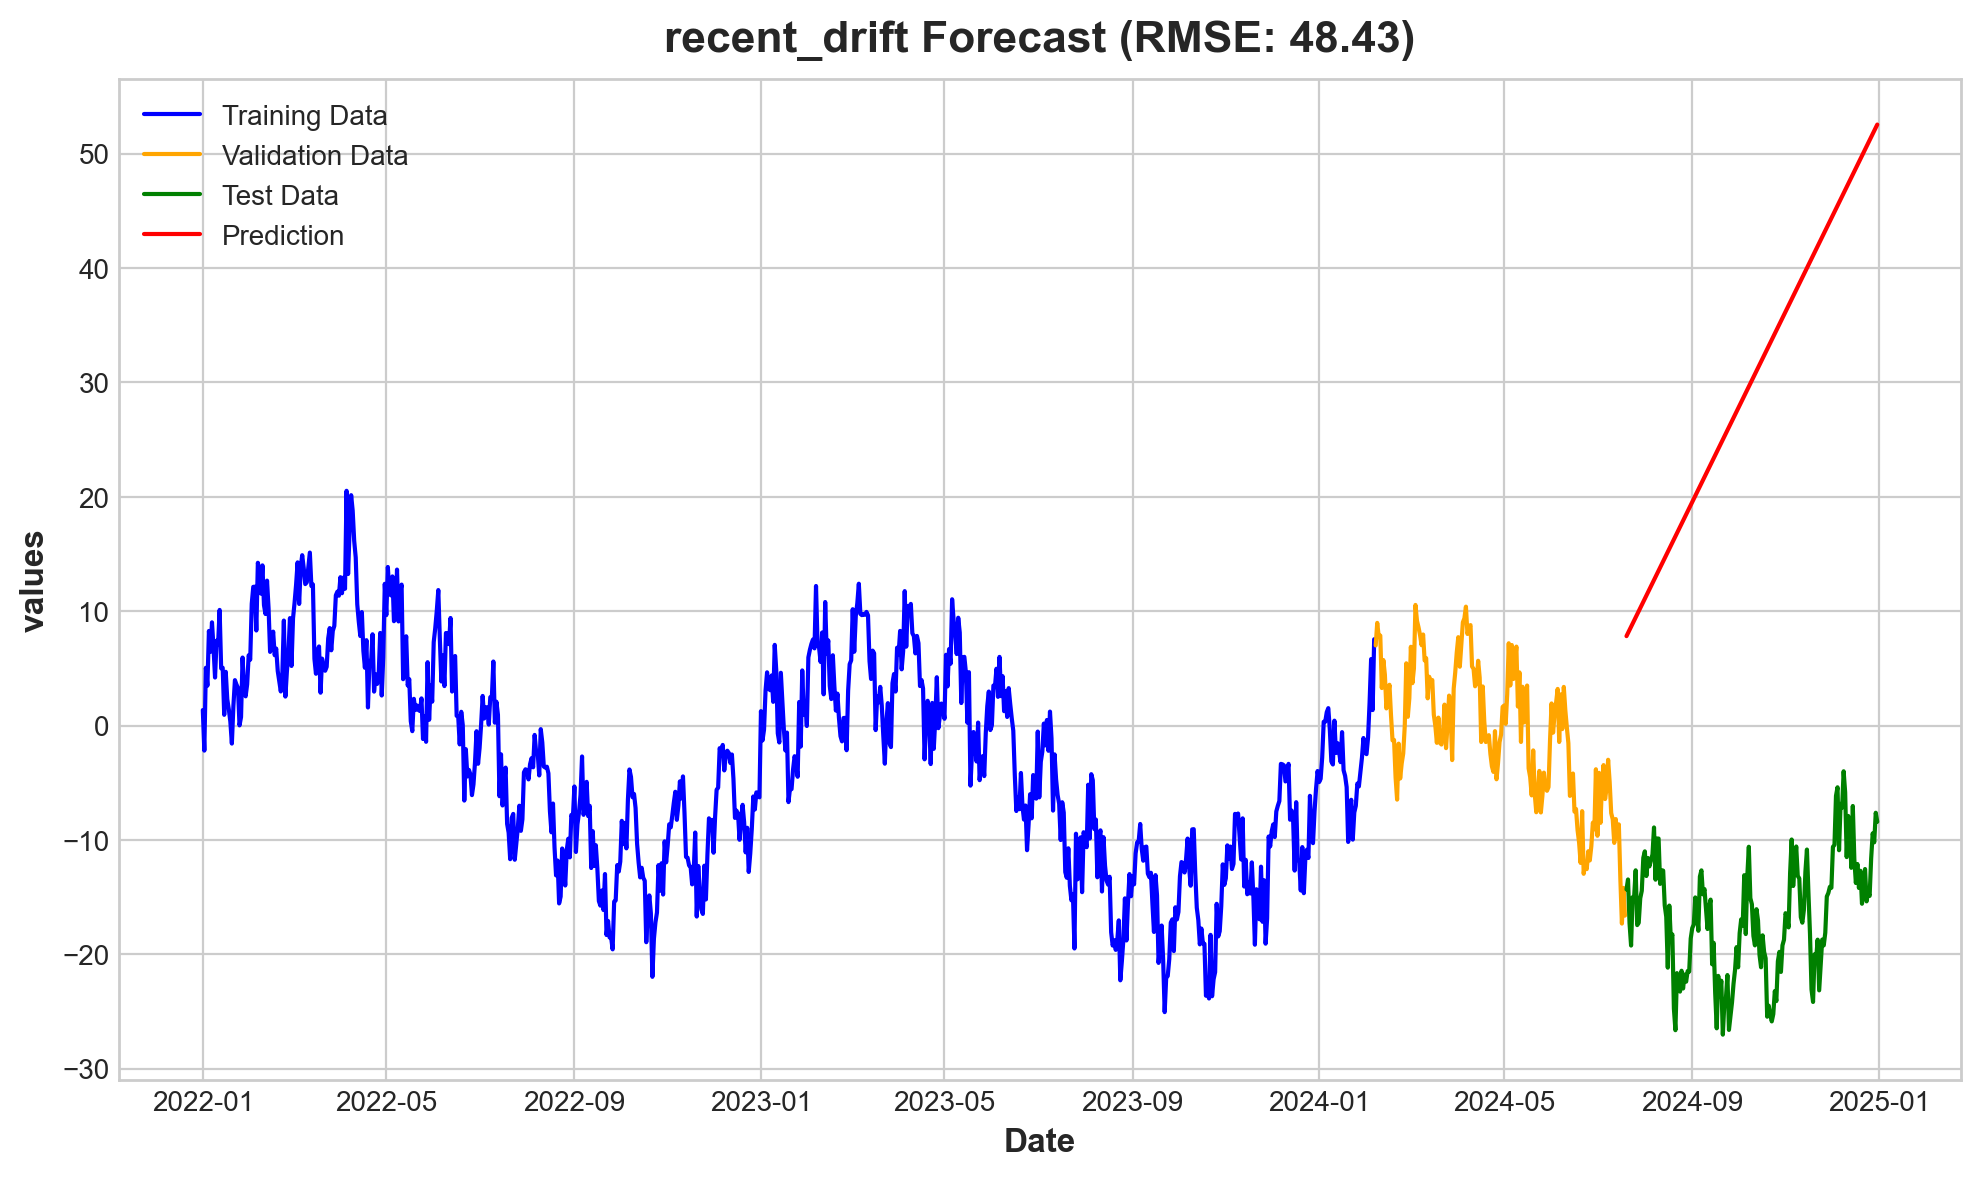

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'recent_drift Forecast (RMSE: 48.43)'}, xlabel='Date', ylabel='values'>)

In [16]:
# plot the train, test and pred
time_series_forecastor.plot_pred_basic(method='recent_drift')

In [17]:
# show the mean square error to check the accuracy
time_series_forecastor.recent_drift_rmse

48.42764820683136

## Seasonality Forecasting model

### Fourier Pairs forecast

Try to get the pair needed by observing the periodogram.

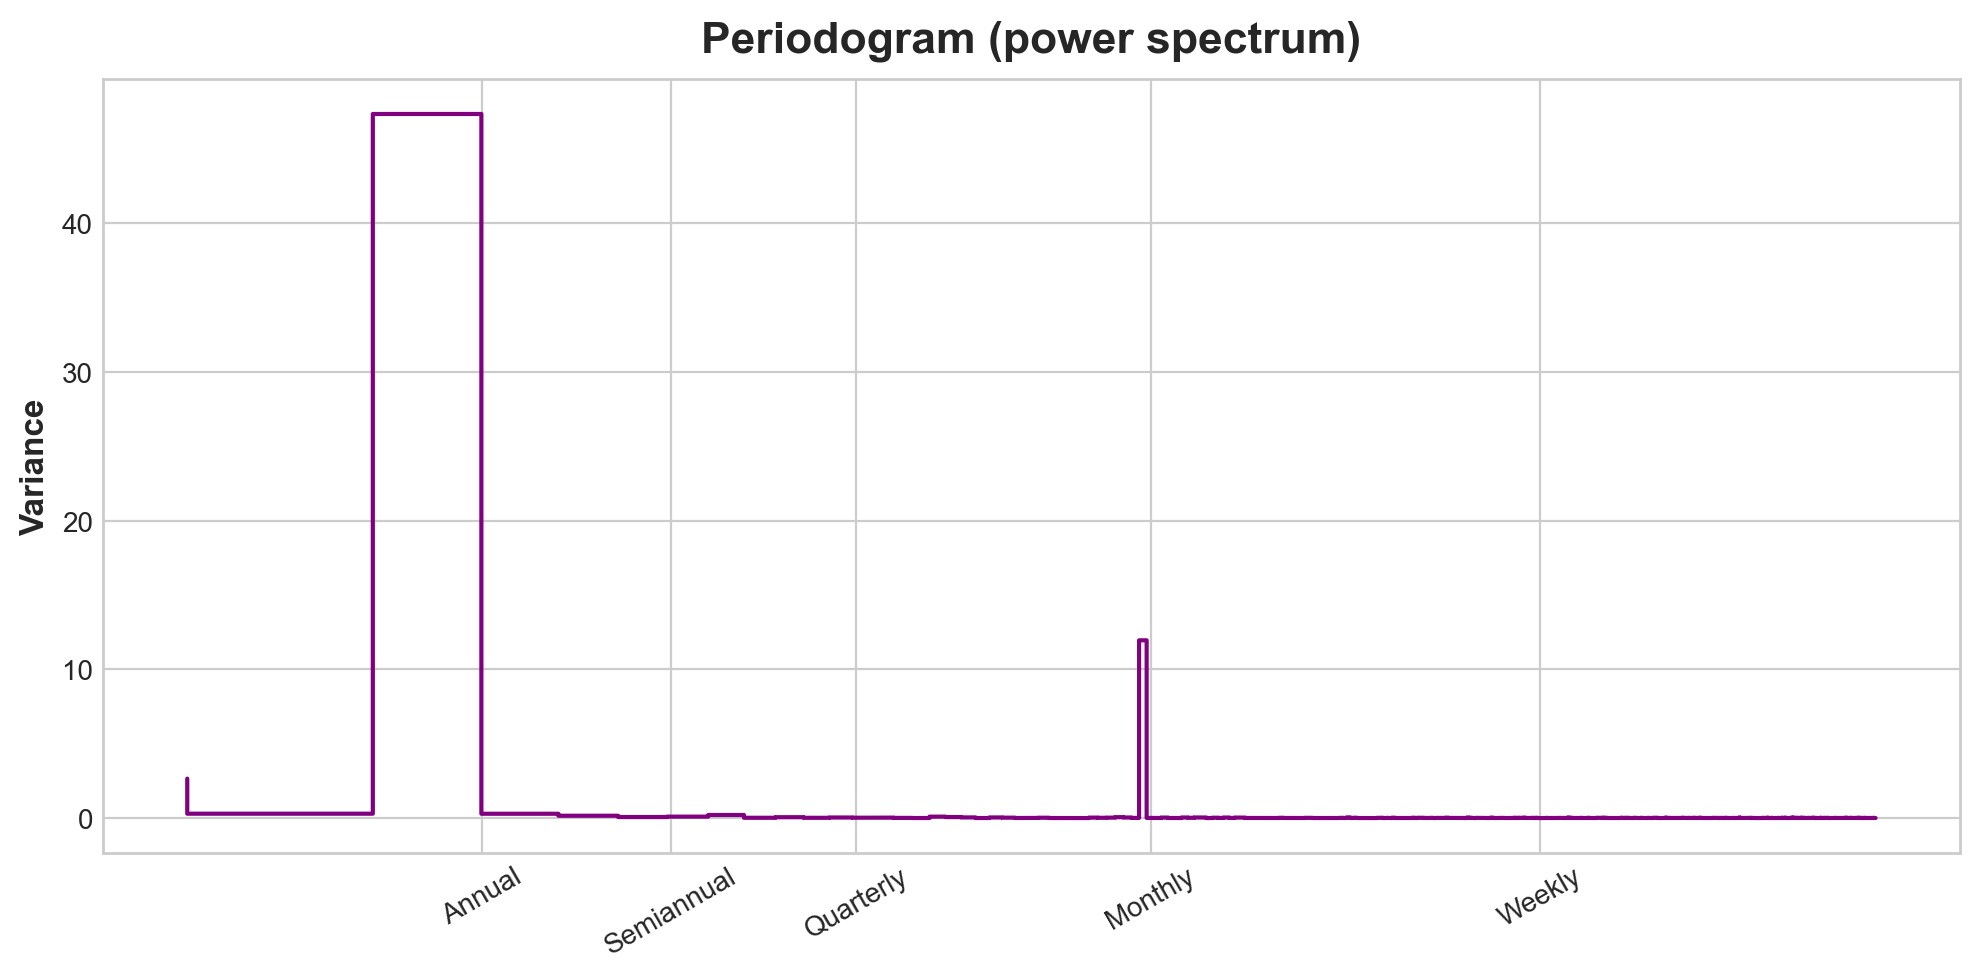

In [18]:
# get the peiordogram to check the pair needed
time_series_forecastor.plot_periodogram();

It's not obvious & may be trying with one pair first.

In [19]:
# TODO: Research the way to intepret the result from the periodogram

In [20]:
# get ready the training part with the fourier features & the deterministic process
X, dp = time_series_forecastor.fourier_features_capture(order = 1)
# get the target training data
y = time_series_forecastor.ts.asfreq('D')

# fit the feature and data into Linear regression and predict for future 90 days as default
y_pred, X_fore, y_fore = time_series_forecastor.fourier_features_forecast(X, y, dp)

## ARIMA Forecasting model

### ARIMA data simulator

We need a data simulator to generate data for testing our ARIMA-related functions and to ensure they work correctly.

In [21]:
# ARIMASimulator imported from estatecnica.time_series.simulation


In [22]:
# Instantiate the simulator
simulator = ARIMASimulator(n_samples=5000)

In [23]:
# Generate data for different situations
df_d0 = simulator.generate_arima_data(d=0, drift=0.2)
df_d1 = simulator.generate_arima_data(d=1, drift=0.2)
df_d2 = simulator.generate_arima_data(d=2, drift=0.2)

### Step 1: Ensure Stationarity

Fine the d value based on ADF Test. It works fine as we are able to see the d value for reference.

In [24]:
time_series_forecastor = TimeSeriesForcastor(df_d0, date_column = 'date', value_column = 'value')
d, ts = time_series_forecastor.find_d_parameter()

--- Time Series Split ---
Training Set:   3500 points (2020-01-01 to 2029-07-31)
Validation Set: 750 points (2029-08-01 to 2031-08-20)
Test Set:       750 points (2031-08-21 to 2033-09-08)

--- Finding Optimal 'd' Parameter ---
Testing with d = 0...
  ADF p-value: 0.0000
  Result: Series is stationary. Optimal d = 0


In [25]:
time_series_forecastor = TimeSeriesForcastor(df_d1, date_column = 'date', value_column = 'value')
d, ts = time_series_forecastor.find_d_parameter()

--- Time Series Split ---
Training Set:   3500 points (2020-01-01 to 2029-07-31)
Validation Set: 750 points (2029-08-01 to 2031-08-20)
Test Set:       750 points (2031-08-21 to 2033-09-08)

--- Finding Optimal 'd' Parameter ---
Testing with d = 0...
  ADF p-value: 0.9981
  Result: Series is non-stationary. Differencing...
Testing with d = 1...
  ADF p-value: 0.0000
  Result: Series is stationary. Optimal d = 1


In [26]:
time_series_forecastor = TimeSeriesForcastor(df_d2, date_column = 'date', value_column = 'value')
d, ts = time_series_forecastor.find_d_parameter()

--- Time Series Split ---
Training Set:   3500 points (2020-01-01 to 2029-07-31)
Validation Set: 750 points (2029-08-01 to 2031-08-20)
Test Set:       750 points (2031-08-21 to 2033-09-08)

--- Finding Optimal 'd' Parameter ---
Testing with d = 0...
  ADF p-value: 0.3105
  Result: Series is non-stationary. Differencing...
Testing with d = 1...
  ADF p-value: 0.4969
  Result: Series is non-stationary. Differencing...
Testing with d = 2...
  ADF p-value: 0.0000
  Result: Series is stationary. Optimal d = 2


### Step 2: Identify p and q

After ensure the data is stationary, we'll need to find the p (AR - AutoRegressive) and q value (MA - Moving Average).

- p: The relationship between an observation and a number of lagged observations (past values)
- q: The relationship between an observation and the residual errors from a moving average model applied to lagged observations

#### p value

In [27]:
# Generate data for p = 2 situation
df_p2 = simulator.generate_arima_data(d=0, p_coeffs=[0.7, -0.3])

In [28]:
time_series_forecastor = TimeSeriesForcastor(df_p2, date_column = 'date', value_column = 'value')

--- Time Series Split ---
Training Set:   3500 points (2020-01-01 to 2029-07-31)
Validation Set: 750 points (2029-08-01 to 2031-08-20)
Test Set:       750 points (2031-08-21 to 2033-09-08)


In [29]:
# make sure the time series become stationary
d, ts = time_series_forecastor.find_d_parameter()


--- Finding Optimal 'd' Parameter ---
Testing with d = 0...
  ADF p-value: 0.0000
  Result: Series is stationary. Optimal d = 0



=== AUTOCORRELATION ANALYSIS ===


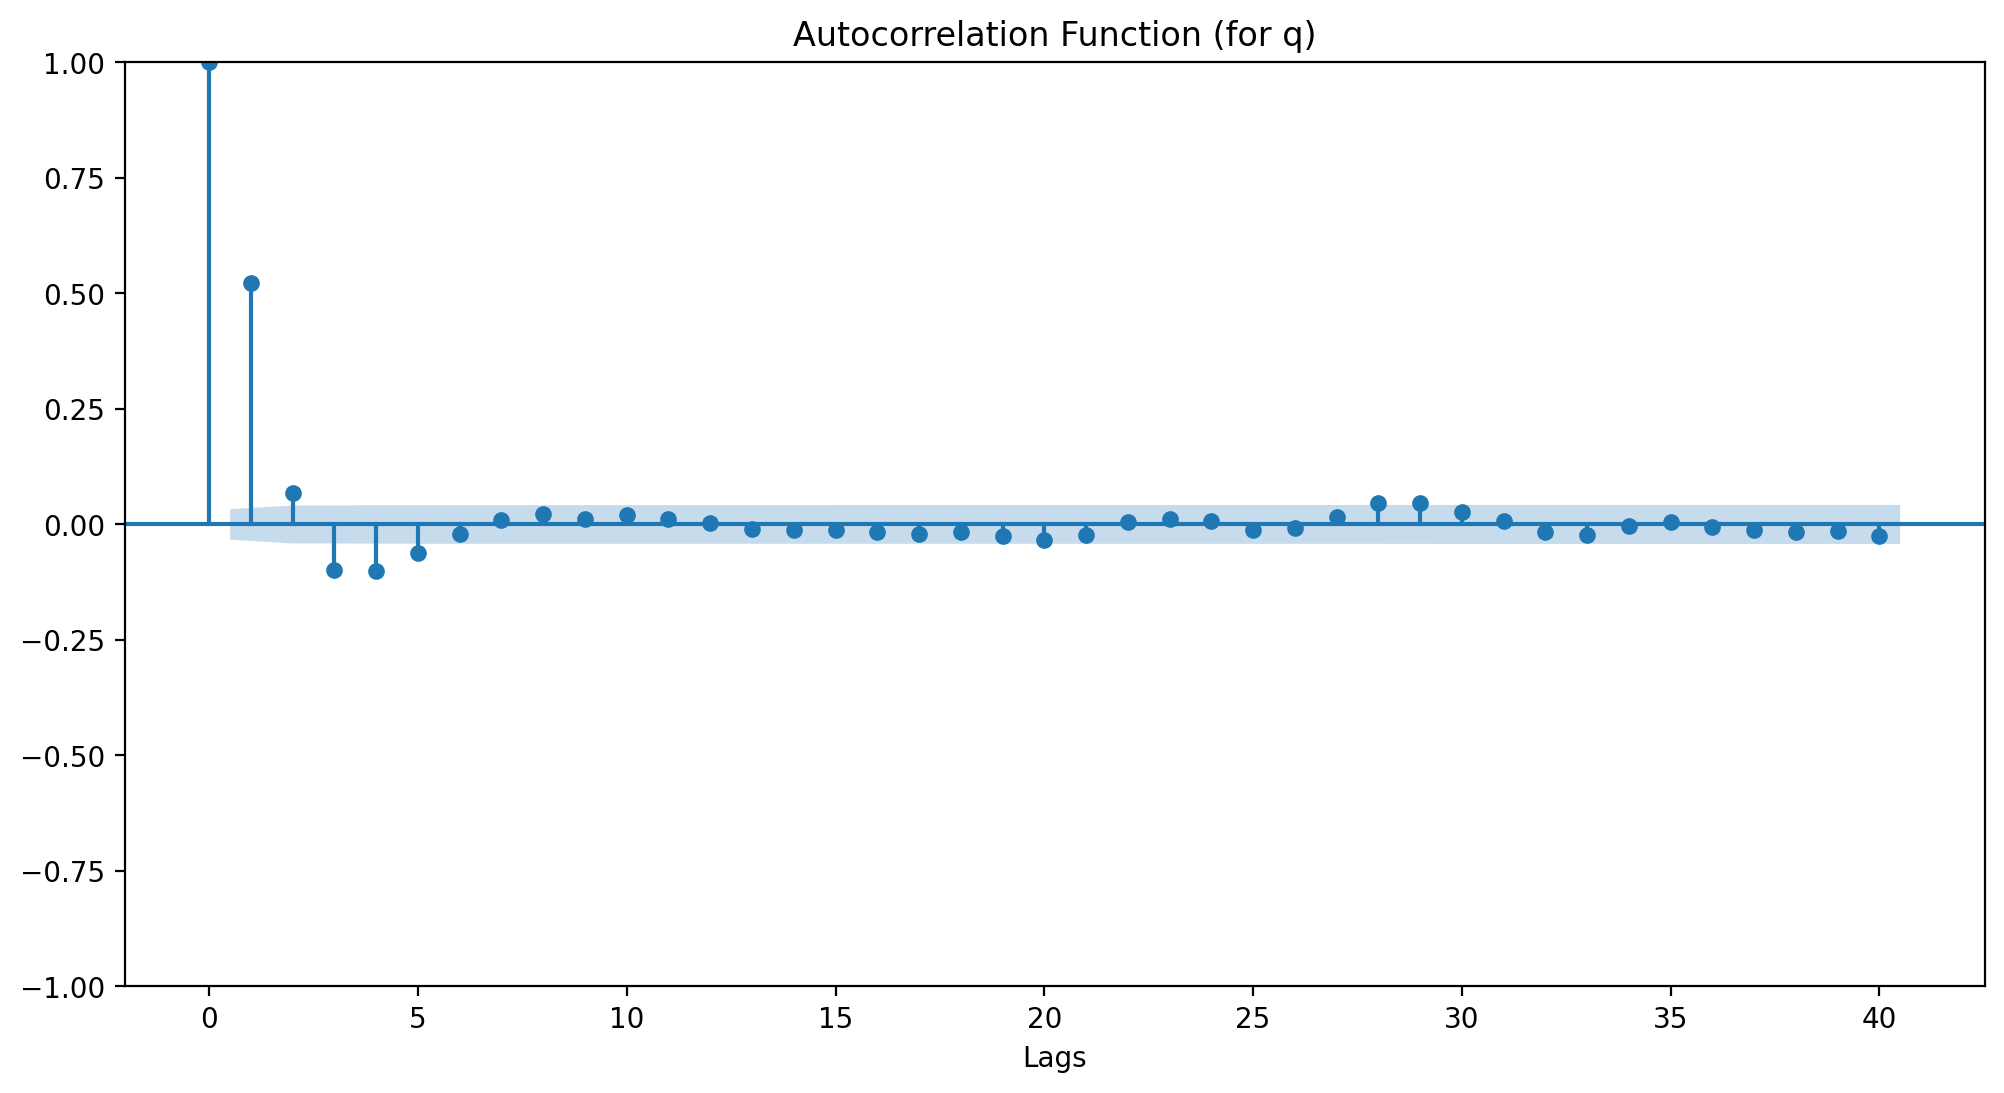

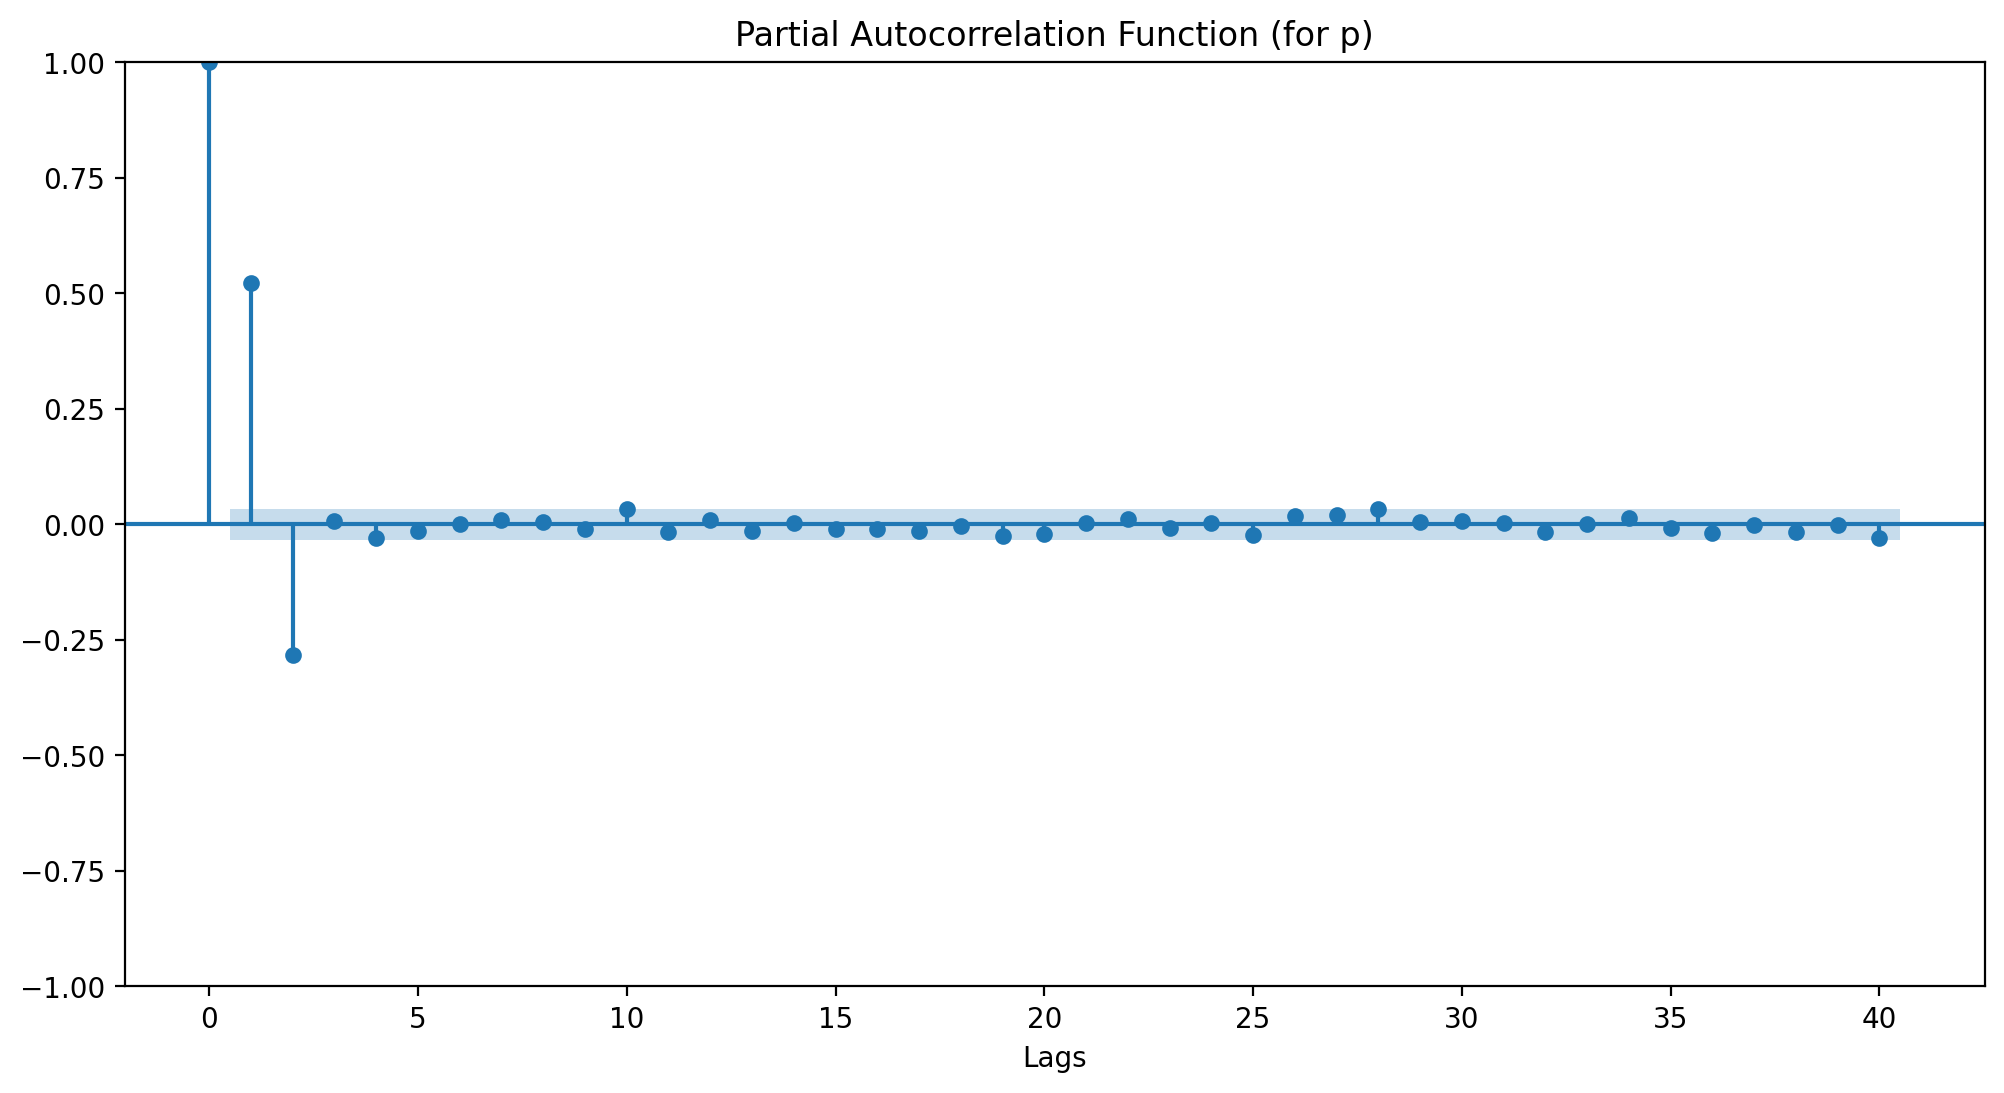


=== Overall correlation in daily ===
Lag 7 autocorrelation: 0.0084
Lag 30 autocorrelation: 0.0092
Lag 90 autocorrelation: -0.0151
Lag 180 autocorrelation: 0.0067
Lag 365 autocorrelation: -0.0202

--- Initial ARIMA Parameter Suggestion ---
The shaded area is the 95% confidence interval.
Spikes outside this area are statistically significant.

Suggested q value (from ACF cut-off): 5
Suggested p value (from PACF cut-off): 2

Note: These are starting points. Always test different parameter combinations.


In [30]:
suggestion = time_series_forecastor.autocorrelation_analysis(diffed_ts=ts, find_pq=True)["order_suggestion"]
suggestion.q_suggest, suggestion.p_suggest


#### q value

In [31]:
# Generate data for p = 1 situation
df_q1 = simulator.generate_arima_data(d=1,  q_coeffs=[0.8])

In [32]:
time_series_forecastor = TimeSeriesForcastor(df_q1, date_column = 'date', value_column = 'value')

--- Time Series Split ---
Training Set:   3500 points (2020-01-01 to 2029-07-31)
Validation Set: 750 points (2029-08-01 to 2031-08-20)
Test Set:       750 points (2031-08-21 to 2033-09-08)


In [33]:
# make sure the time series become stationary
d, ts = time_series_forecastor.find_d_parameter()


--- Finding Optimal 'd' Parameter ---
Testing with d = 0...
  ADF p-value: 0.6889
  Result: Series is non-stationary. Differencing...
Testing with d = 1...
  ADF p-value: 0.0000
  Result: Series is stationary. Optimal d = 1



=== AUTOCORRELATION ANALYSIS ===


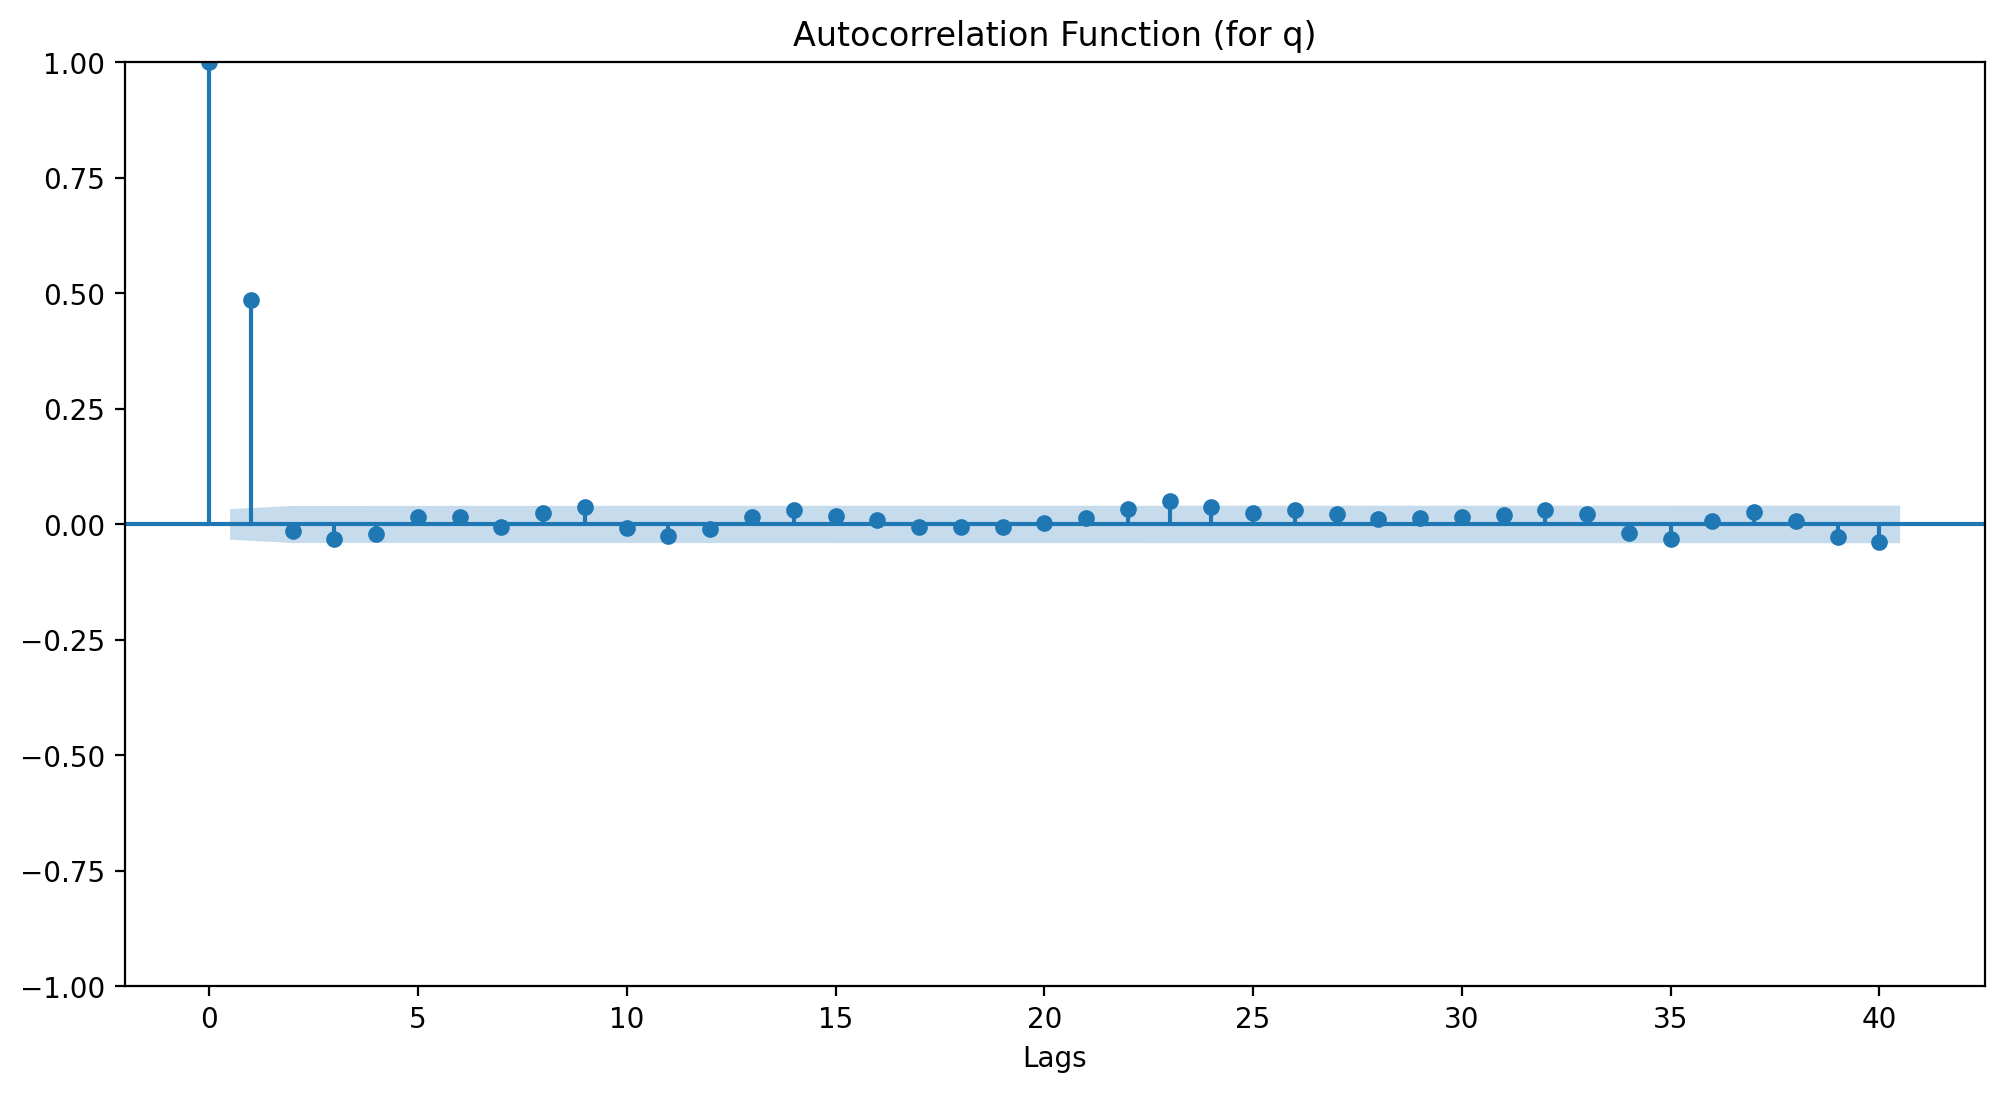

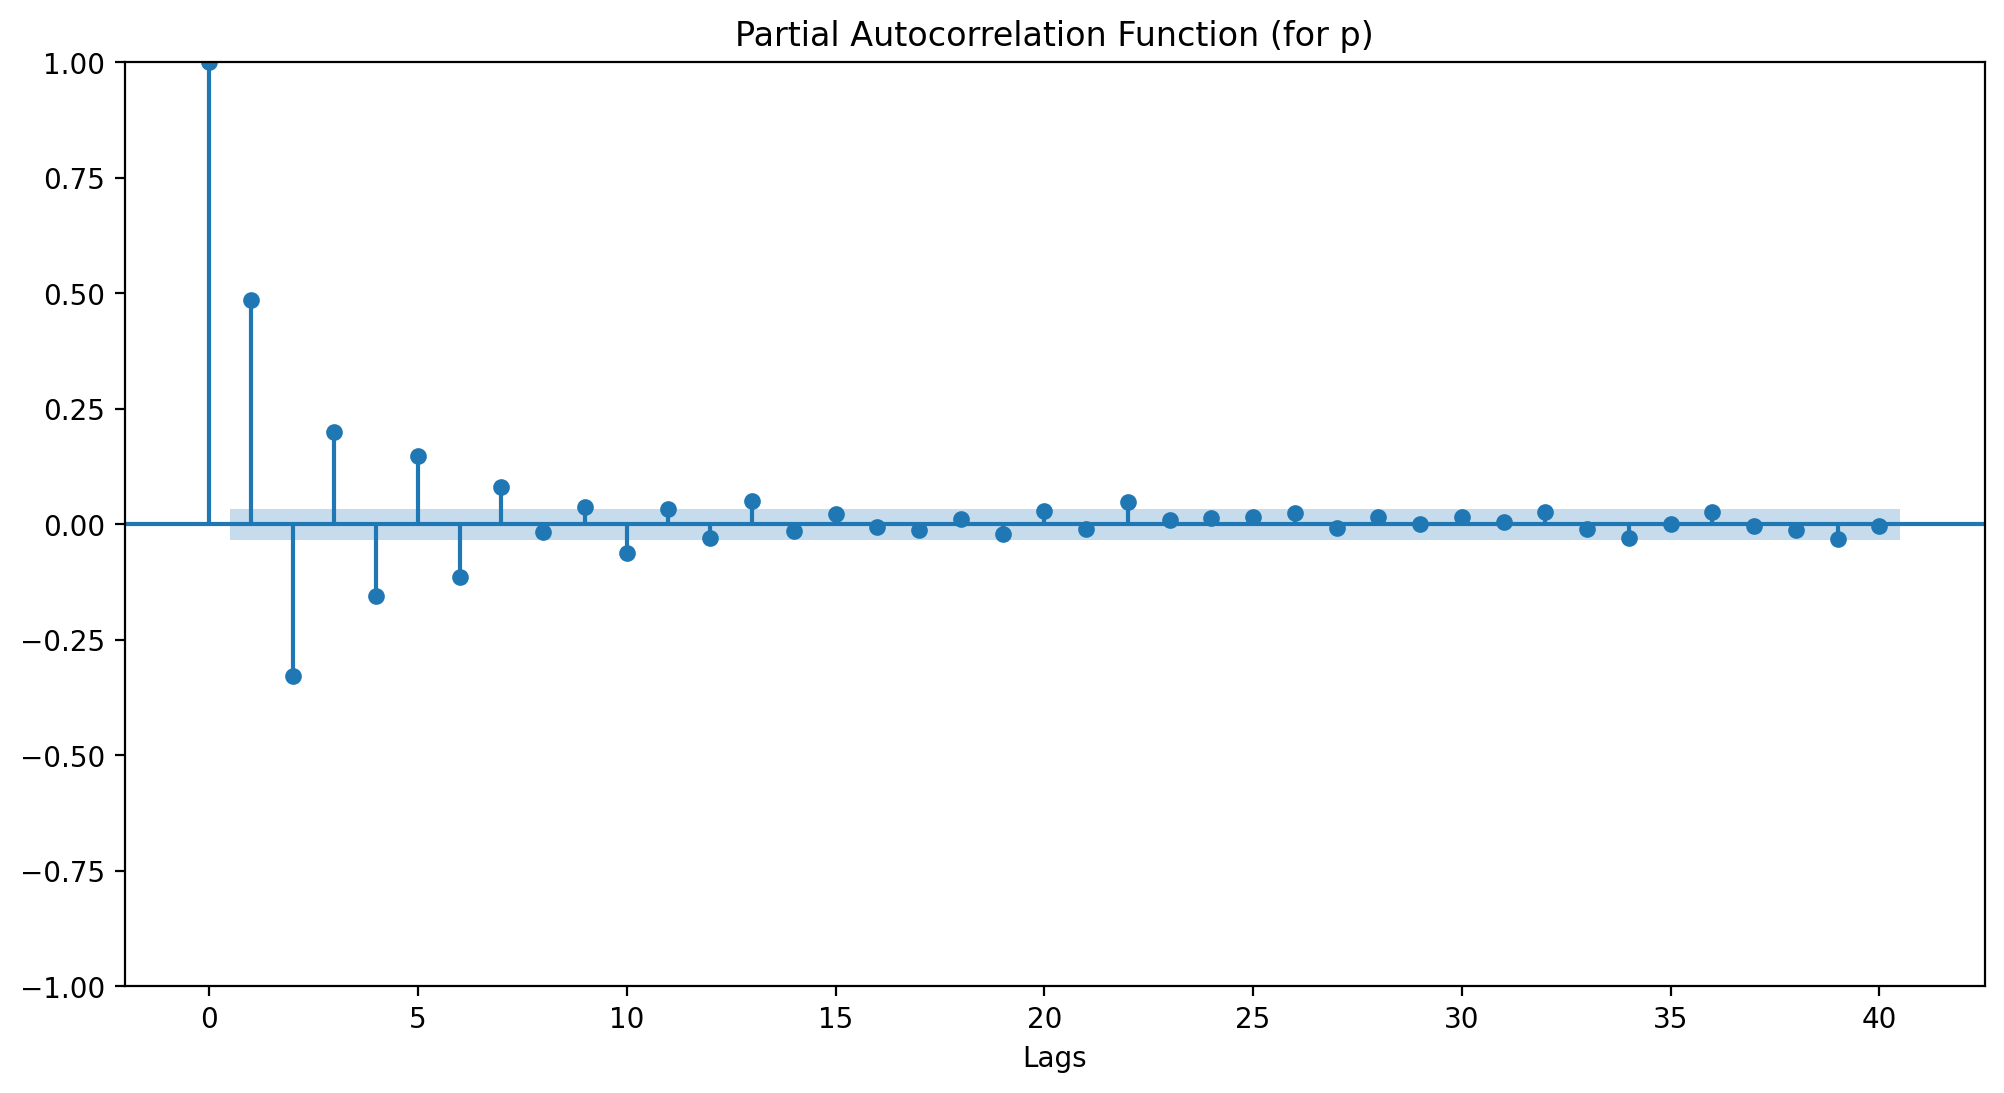


=== Overall correlation in daily ===
Lag 7 autocorrelation: 0.9963
Lag 30 autocorrelation: 0.9817
Lag 90 autocorrelation: 0.9432
Lag 180 autocorrelation: 0.8873
Lag 365 autocorrelation: 0.7662

--- Initial ARIMA Parameter Suggestion ---
The shaded area is the 95% confidence interval.
Spikes outside this area are statistically significant.

Suggested q value (from ACF cut-off): 1
Suggested p value (from PACF cut-off): 13

Note: These are starting points. Always test different parameter combinations.


In [34]:
suggestion = time_series_forecastor.autocorrelation_analysis(diffed_ts=ts, find_pq=True)["order_suggestion"]
suggestion.q_suggest, suggestion.p_suggest


In [35]:
# TODO: Time series feature Time Step & Lag_1